# Inicializando las librerias que se van a ocupar

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report

In [2]:
base = pd.read_csv('/content/datos_tratados.csv')
base.shape

(7043, 21)

# Conociendo los datos

In [3]:
base.sample(5)

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
5795,0,Female,0,0,0,7,1,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,1,Electronic check,66.85,458.10,2.228333
6130,0,Male,0,0,0,29,1,No,DSL,Yes,...,No,Yes,No,No,One year,1,Electronic check,58.75,1696.20,1.958333
5755,0,Male,0,1,1,59,1,No,DSL,No,...,Yes,Yes,Yes,Yes,One year,0,Credit card (automatic),76.75,4541.90,2.558333
4553,0,Male,0,1,0,51,1,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),83.25,4089.45,2.775000
2806,1,Female,0,0,0,6,1,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,1,Credit card (automatic),109.90,669.45,3.663333


In [5]:
base = base.drop(['gender', 'Contract', 'PaymentMethod'],axis=1)

In [6]:
X = base.drop('Churn',axis=1)
Y = base['Churn']
print(X.shape)
print(Y.shape)

(7043, 17)
(7043,)


In [7]:
columnas = X.columns
columnas

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_diarias'],
      dtype='object')

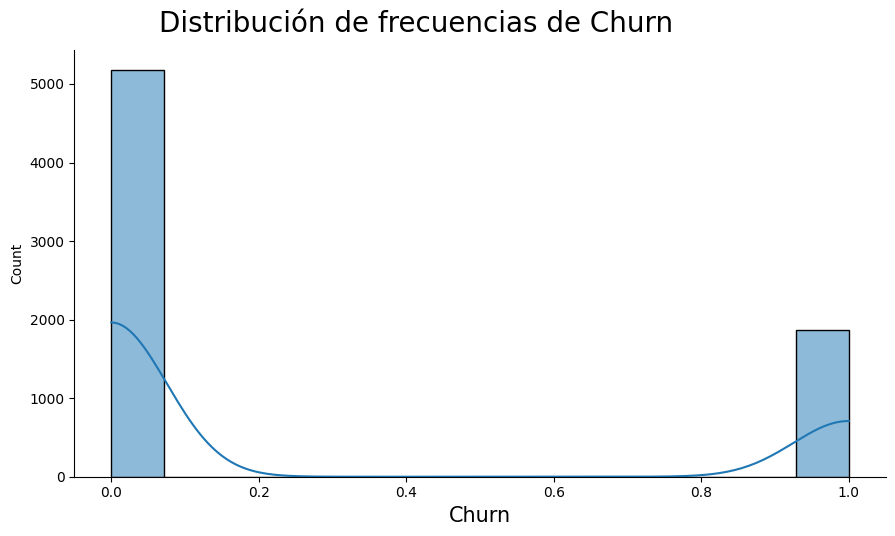

In [8]:
ax = sns.displot(base['Churn'], kde = True)
ax.figure.set_size_inches(10,5)
ax.fig.suptitle('Distribución de frecuencias de Churn', fontsize=20, y=1.05)
ax.set_xlabels("Churn", fontsize=15)
ax;

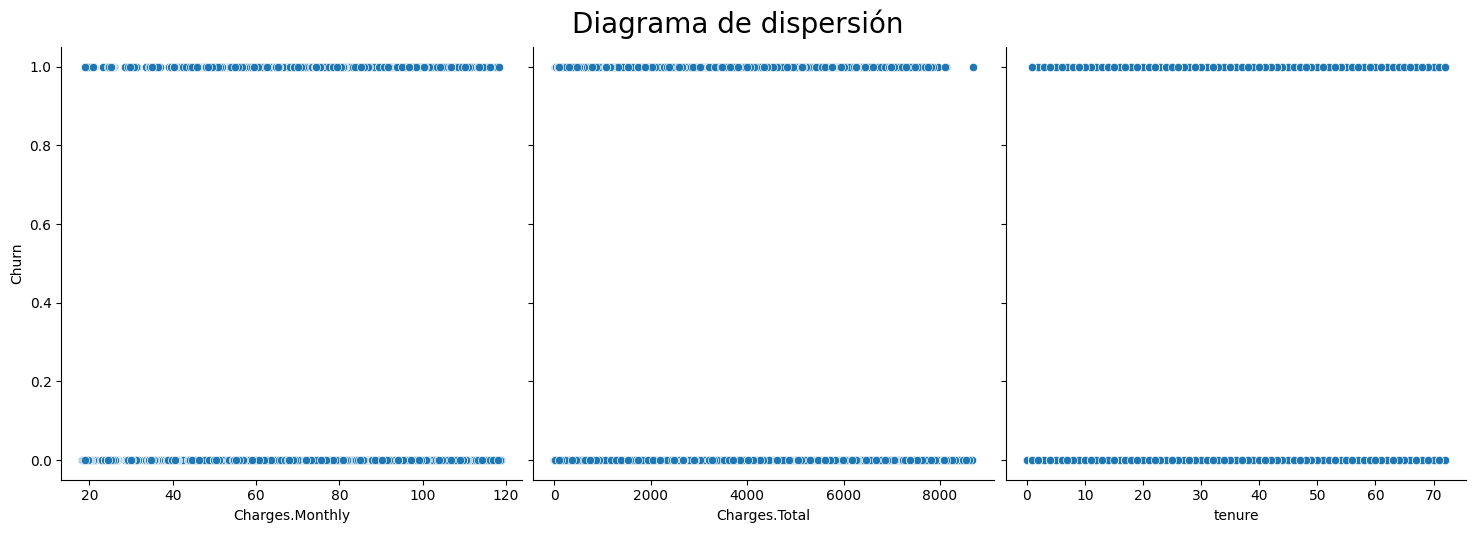

In [9]:
ax = sns.pairplot(base, y_vars='Churn', x_vars=[ 'Charges.Monthly', 'Charges.Total', 'tenure'], height=5)
ax.fig.suptitle('Diagrama de dispersión', fontsize=20, y=1.05)
ax;

# Preparar el modelo de predicción

In [12]:
one_hot = make_column_transformer(
          (OneHotEncoder(drop='if_binary'), ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']),
          remainder = 'passthrough',
          sparse_threshold=0,
          force_int_remainder_cols=False
          )


In [13]:
X = one_hot.fit_transform(X)

In [14]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__OnlineSecurity_No',
       'onehotencoder__OnlineSecurity_No internet service',
       'onehotencoder__OnlineSecurity_Yes',
       'onehotencoder__OnlineBackup_No',
       'onehotencoder__OnlineBackup_No internet service',
       'onehotencoder__OnlineBackup_Yes',
       'onehotencoder__DeviceProtection_No',
       'onehotencoder__DeviceProtection_No internet service',
       'onehotencoder__DeviceProtection_Yes',
       'onehotencoder__TechSupport_No',
       'onehotencoder__TechSupport_No internet service',
       'onehotencoder__TechSupport_Yes', 'onehotencoder__StreamingTV_No',
       'onehotencoder__StreamingTV_No internet service',
       'onehotencoder__StreamingTV_Yes',
       

In [15]:
X

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        6.56000000e+01, 5.93300000e+02, 2.18666667e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        5.99000000e+01, 5.42400000e+02, 1.99666667e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        7.39000000e+01, 2.80850000e+02, 2.46333333e+00],
       ...,
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.03000000e+01, 9.27500000e+01, 1.67666667e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        6.78500000e+01, 4.62765000e+03, 2.26166667e+00],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        5.90000000e+01, 3.70760000e+03, 1.96666667e+00]])

In [16]:
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)
Y

array([0, 0, 1, ..., 0, 0, 0])

## Proporción de clientes activos vs clientes cancelados

### Se observa que existe una desproporción entre los clientes activos vs clientes cancelados, por lo que se sugiere un undersampling

In [17]:
Participación = base.groupby(['Churn'])['Churn'].count().reset_index(name="Conteo")
Participación['Porcentaje'] = round(Participación['Conteo'] / Participación['Conteo'].sum() * 100, 2)
Participación

,Churn,Conteo,Porcentaje
0,0,5174,73.46
1,1,1869,26.54


In [18]:
X, X_test, Y, Y_test = train_test_split(X, Y, test_size=0.20, stratify=Y, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.20, stratify=Y, random_state=5)

# Generando modelo Undersample

In [19]:
#Pipeline Undersampling

modelo_undersampling = DecisionTreeClassifier(max_depth=5)
pipeline = Pipeline([('undersample', NearMiss(version = 3)), ('arbol',modelo_undersampling)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados_undersampling = cross_validate(pipeline, X, Y, cv=skf, scoring='recall')
print(f'El test_score promedio es de : {round(cv_resultados_undersampling['test_score'].mean(),4)}')
print(pd.DataFrame(cv_resultados_undersampling))

El test_score promedio es de : 0.695
   fit_time  score_time  test_score
0  0.290812    0.019714    0.715719
1  0.213988    0.005961    0.672241
2  0.095817    0.005473    0.755853
3  0.109457    0.012173    0.571906
4  0.117034    0.006092    0.759197


              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1035
           1       0.53      0.57      0.55       374

    accuracy                           0.75      1409
   macro avg       0.69      0.70      0.69      1409
weighted avg       0.76      0.75      0.76      1409



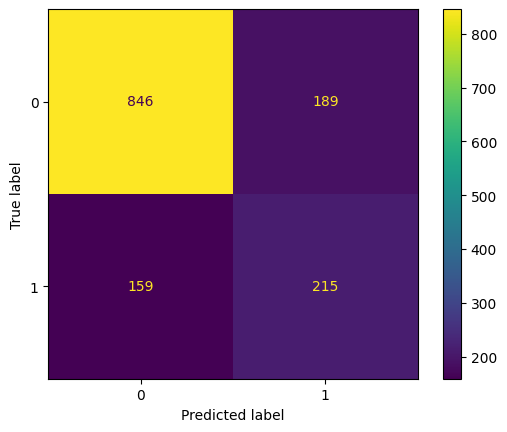

In [20]:
undersample = NearMiss(version = 3)
X_balanceada, Y_balanceada = undersample.fit_resample(X, Y)

modelo_undersampling = DecisionTreeClassifier(max_depth=5)
modelo_undersampling.fit(X_balanceada, Y_balanceada)
Y_previsto_undersampling = modelo_undersampling.predict(X_test)
print(classification_report(Y_test, Y_previsto_undersampling))
ConfusionMatrixDisplay.from_predictions(Y_test,Y_previsto_undersampling);

In [24]:
nombres_columnas = one_hot.get_feature_names_out()
importancias = modelo_undersampling.feature_importances_

importancia_variables = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
})

importancia_variables = importancia_variables.sort_values(by='Importancia', ascending=False)

importancia_variables.head(10)

,Variable,Importancia
27,remainder__tenure,0.599966
15,onehotencoder__TechSupport_No,0.126728
32,remainder__Cuentas_diarias,0.065218
8,onehotencoder__OnlineSecurity_Yes,0.057714
29,remainder__PaperlessBilling,0.034402
6,onehotencoder__OnlineSecurity_No,0.030327
0,onehotencoder__MultipleLines_No,0.022442
3,onehotencoder__InternetService_DSL,0.013740
31,remainder__Charges.Total,0.013149
23,onehotencoder__StreamingMovies_Yes,0.009544


# Creando modelo Oversample

In [21]:
#Pipeline Oversampling

modelo_oversampling = DecisionTreeClassifier(max_depth=5)
pipeline = Pipeline([('oversample', SMOTE()), ('arbol',modelo_oversampling)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados_oversampling = cross_validate(pipeline, X, Y, cv=skf, scoring='recall')
print(f'El test_score promedio es de : {round(cv_resultados_oversampling['test_score'].mean(),4)}')
print(pd.DataFrame(cv_resultados_oversampling))

El test_score promedio es de : 0.7003
   fit_time  score_time  test_score
0  0.222488    0.018940    0.732441
1  0.181624    0.005832    0.628763
2  0.190934    0.019232    0.678930
3  0.123447    0.008763    0.719064
4  0.143179    0.008766    0.742475


              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.51      0.74      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.76      1409



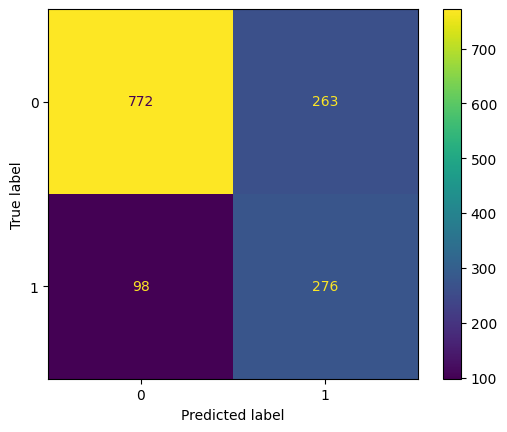

In [22]:
oversampling =  SMOTE()
X_balanceada, Y_balanceada = oversampling.fit_resample(X, Y)

modelo_oversampling = DecisionTreeClassifier(max_depth=5)
modelo_oversampling.fit(X_balanceada, Y_balanceada)
Y_previsto_oversampling = modelo_oversampling.predict(X_test)
print(classification_report(Y_test, Y_previsto_oversampling))
ConfusionMatrixDisplay.from_predictions(Y_test,Y_previsto_oversampling);

In [23]:
nombres_columnas = one_hot.get_feature_names_out()
importancias = modelo_oversampling.feature_importances_

importancia_variables = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
})

importancia_variables = importancia_variables.sort_values(by='Importancia', ascending=False)

importancia_variables.head(10)

,Variable,Importancia
6,onehotencoder__OnlineSecurity_No,0.501964
17,onehotencoder__TechSupport_Yes,0.156408
27,remainder__tenure,0.106094
11,onehotencoder__OnlineBackup_Yes,0.051274
4,onehotencoder__InternetService_Fiber optic,0.039138
9,onehotencoder__OnlineBackup_No,0.036728
31,remainder__Charges.Total,0.029320
8,onehotencoder__OnlineSecurity_Yes,0.028874
15,onehotencoder__TechSupport_No,0.024883
29,remainder__PaperlessBilling,0.009454


# Conclusiones

Con base al análisis exploratorio de la información, se identificó que existe un desbalanceo importante en la variable a explicar, el 73% de los datos correspondían a los clientes que actualmente no tienen un contrato de servicio por ello se generaron dos modelos de predicción:

En ambos casos, se busca tener un balance entre las clases de la variable a explicar, es decir, que del total de observaciones, el 50% sean de la clase
"Yes" y el otro 50% sean de la clase "No".

1.- Undersample: toma una muestra reducida de la clase que tiene más elementos, ajustándola al número de elementos de la clase con menos elementos.

- Se utiliza la metodología NearMiss

2.- Oversample: aumenta la cantidad de datos de la clase minoritaria copiando o generando nuevos ejemplos.

- Se utiliza la metodología SMOTE



## Comparación de resultados

El objetivo de ambos ejercicios es el predecir un cliente que termina su contrato de servicio con la empresa.

|Modelo       | Precision | Recall    | F1-Score  |
|-------------|-----------|-----------|-----------|
| Undersample | 0.84      | 0.82      | 0.83      |
| Oversample  | 0.89      | 0.75      | 0.81      |

- El modelo Undersample muestra un mejor performance ya que logra detectar más clientes con potencial a terminar el contrato.

- Las variables que más influye en la decisión de continuar o no con el servicio son remainder__tenure y onehotencoder__TechSupport_No